<a href="https://colab.research.google.com/github/acrissguimaraes/my-lab/blob/main/Sales_Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Global Superstore Sales: A Data-Driven Study on Profitability and Market Performance

Dataset: Superstore Sales & Logistics Dataset

Core Topic: Sales Optimization and Profit Margin Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Business Understanding



* Which category sells the most?
* Where do we have the highest profit or the biggest losses?
* Which regions are performing the best?







Data understanding

In [4]:
df = pd.read_csv("/Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
print(df.shape)
print(df.columns)

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


Data Preparation

In [14]:
df_view = df[['Order Date', 'Region', 'Category', 'Sales', 'Profit', 'Discount']]
df_view.head()

,Order Date,Region,Category,Sales,Profit,Discount
0,2016-11-08,South,Furniture,261.9600,41.9136,0.00
1,2016-11-08,South,Furniture,731.9400,219.5820,0.00
2,2016-06-12,West,Office Supplies,14.6200,6.8714,0.00
3,2015-10-11,South,Furniture,957.5775,-383.0310,0.45
4,2015-10-11,South,Office Supplies,22.3680,2.5164,0.20


In [17]:
df['Profit_Status'] = df['Profit'].apply(lambda x: 'Profit' if x > 0 else ('Loss' if x < 0 else 'Breakeven'))
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit_Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Profit


In [21]:
df['Ship_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Ship_Performance'] = pd.cut(
    df['Ship_Time'],
    bins=[0, 2, 5, 10, 100],
    labels=['Fast (0-2 days)', 'Normal (3-5 days)', 'Slow (6-10 days)', 'Very Slow (10+)'],
    include_lowest=True
)

df['Sales_Range'] = pd.cut(
    df['Sales'],
    bins=[0, 100, 500, 1000, df['Sales'].max()],
    labels=['Small', 'Medium', 'Big Ticket', 'Enterprise'],
    include_lowest=True
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit_Status,Ship_Time,Ship_Performance,Sales_Range
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Profit,3,Normal (3-5 days),Medium
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Profit,3,Normal (3-5 days),Big Ticket
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Profit,4,Normal (3-5 days),Small
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Loss,7,Slow (6-10 days),Big Ticket
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Profit,7,Slow (6-10 days),Small


Data Visualization & Insights

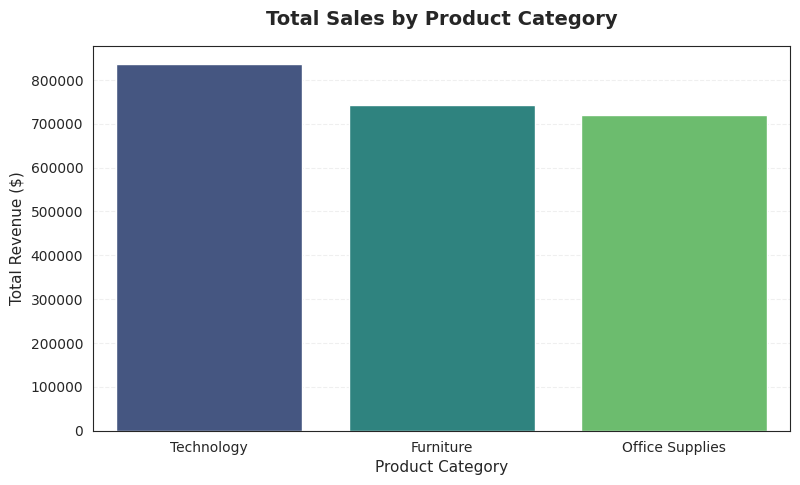

In [22]:
plt.figure(figsize=(9, 5))
sns.set_style("white")
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_sales, x='Category', y='Sales', palette="viridis", hue='Category', legend=False)
plt.title("Total Sales by Product Category", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Total Revenue ($)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

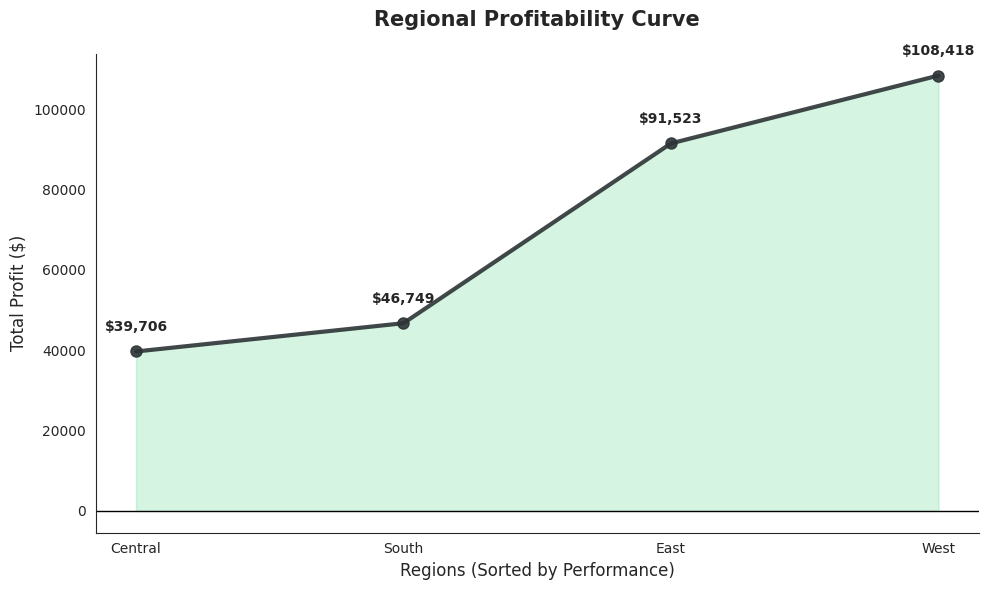

In [32]:
plt.figure(figsize=(10, 6))
sns.set_style("white")

region_detail = df.groupby('Region')['Profit'].sum().sort_values().reset_index()

plt.plot(region_detail['Region'], region_detail['Profit'], color='#2d3436', linewidth=3, marker='o', markersize=8, alpha=0.9)
plt.fill_between(region_detail['Region'], region_detail['Profit'], color='#2ecc71', alpha=0.2)

plt.title("Regional Profitability Curve", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Regions (Sorted by Performance)", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)
sns.despine()

plt.axhline(0, color='black', lw=1, ls='-')
for i, v in enumerate(region_detail['Profit']):
    plt.text(i, v + 5000, f"${v:,.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

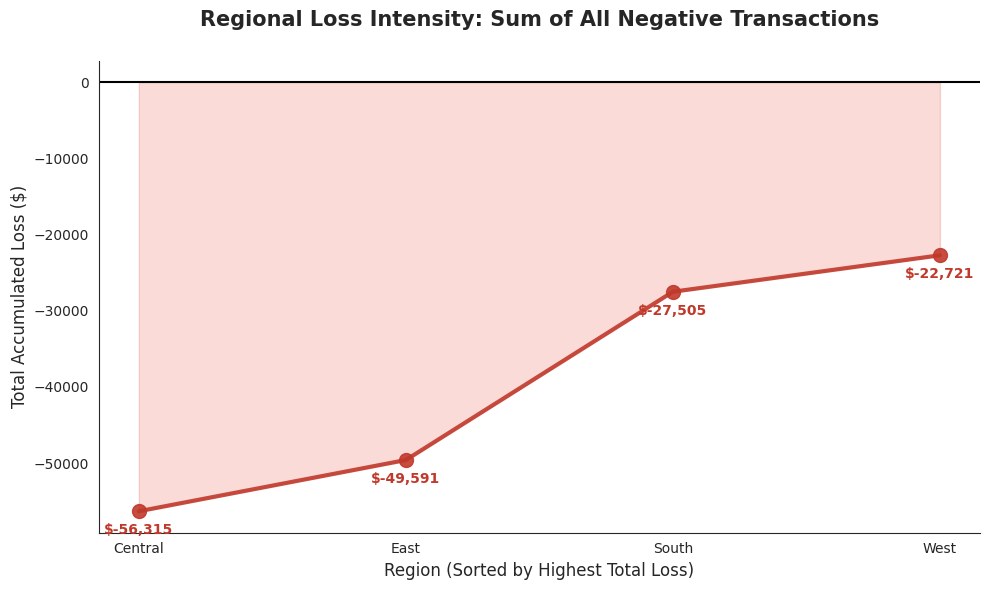

In [39]:
# 1. Setup the figure and minimalist style
plt.figure(figsize=(10, 6))
sns.set_style("white")
region_losses = df[df['Profit'] < 0].groupby('Region')['Profit'].sum().reset_index().sort_values(by='Profit')
plt.plot(region_losses['Region'], region_losses['Profit'], color='#c0392b', linewidth=3, marker='o', markersize=10, alpha=0.9)
plt.fill_between(region_losses['Region'], region_losses['Profit'], color='#e74c3c', alpha=0.2)

plt.title("Regional Loss Intensity: Sum of All Negative Transactions", fontsize=15, fontweight='bold', pad=25)
plt.xlabel("Region (Sorted by Highest Total Loss)", fontsize=12)
plt.ylabel("Total Accumulated Loss ($)", fontsize=12)

sns.despine()

plt.axhline(0, color='black', lw=1.5, ls='-')

for i, v in enumerate(region_losses['Profit']):
    plt.text(i, v - 3000, f"${v:,.0f}", ha='center', fontsize=10, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()

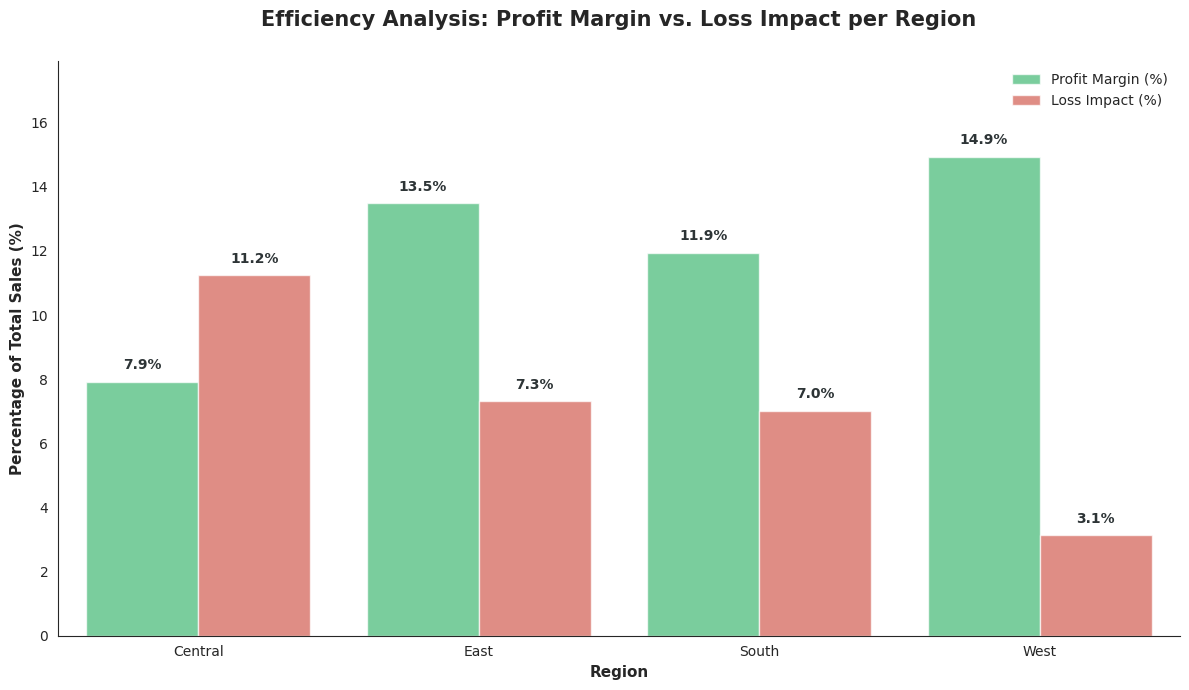

In [71]:
region_stats = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
region_loss_raw = df[df['Profit'] < 0].groupby('Region')['Profit'].sum().reset_index()
region_loss_raw['Profit_Loss'] = region_loss_raw['Profit'].abs()

region_analysis = pd.merge(region_stats, region_loss_raw[['Region', 'Profit_Loss']], on='Region')
region_analysis['Profit Margin (%)'] = (region_analysis['Profit'] / region_analysis['Sales']) * 100
region_analysis['Loss Impact (%)'] = (region_analysis['Profit_Loss'] / region_analysis['Sales']) * 100

plot_data = region_analysis.melt(id_vars='Region', value_vars=['Profit Margin (%)', 'Loss Impact (%)'])
plt.figure(figsize=(12, 7))
sns.set_style("white")

chart = sns.barplot(
    data=plot_data,
    x='Region',
    y='value',
    hue='variable',
    palette=['#2ecc71', '#e74c3c'],
    alpha=0.7,
    linewidth=1
)
max_val = plot_data['value'].max()
plt.ylim(0, max_val * 1.2)

for p in chart.patches:
    height = p.get_height()
    if height > 0:
        chart.annotate(f'{height:.1f}%',
                       (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='center',
                       xytext=(0, 12),
                       textcoords='offset points',
                       fontsize=10,
                       fontweight='bold',
                       color='#2d3436')
plt.title("Efficiency Analysis: Profit Margin vs. Loss Impact per Region", fontsize=15, fontweight='bold', pad=25)
plt.ylabel("Percentage of Total Sales (%)", fontsize=11, fontweight='bold')
plt.xlabel("Region", fontsize=11, fontweight='bold')

plt.legend(title="", frameon=False, loc='upper right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

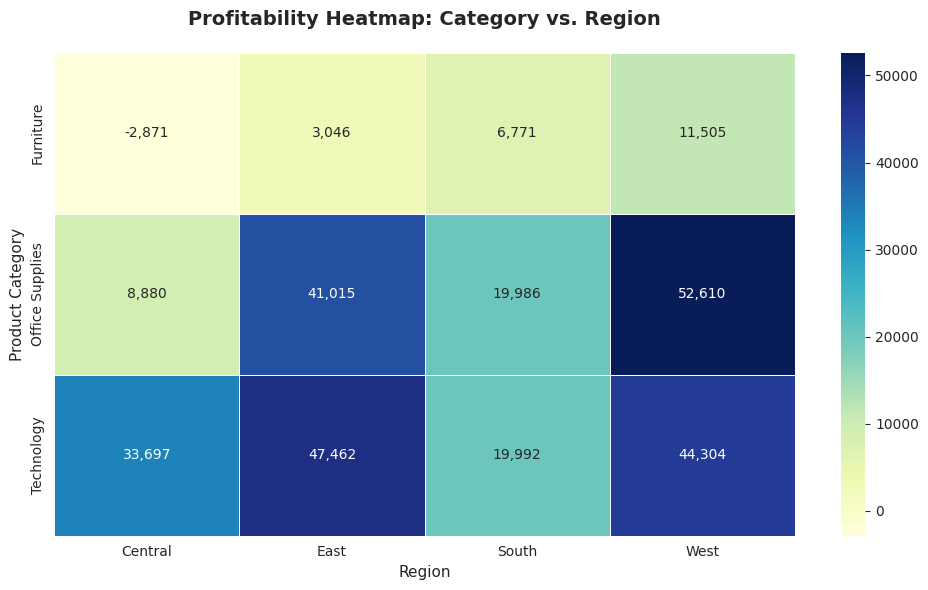

In [42]:
pivot_profit = df.pivot_table(
    index='Category',
    columns='Region',
    values='Profit',
    aggfunc='sum'
)
plt.figure(figsize=(10, 6))
sns.set_style("white")
sns.heatmap(
    pivot_profit,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    cbar=True,
    linewidths=0.5
)

plt.title("Profitability Heatmap: Category vs. Region", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Region", fontsize=11)
plt.ylabel("Product Category", fontsize=11)

plt.tight_layout()
plt.show()

The data reveals that the 'High-Performance' profile is identified within the West Region, driven by the Office Supplies category. While Technology leads the company in overall sales volume, the West + Office Supplies combination demonstrates the highest operational efficiency and consistent profit margins. This indicates that this segment is the most resilient and reliable profit engine for the business.

Conversely, the 'High-Risk' profile is clearly centered in the Central Region, specifically within the Furniture category. This segment is characterized by the deepest financial losses, likely driven by a failure to balance high shipping costs or logistical complexities with sustainable pricing. This suggests that the company must adjust its strategy in this market to avoid eroding overall profits.

Analysis

In [45]:
category_analysis = df.groupby("Category").agg({"Sales": "sum", "Profit": "sum"}).reset_index()
category_analysis["Profit Margin (%)"] = ((category_analysis["Profit"] / category_analysis["Sales"]) * 100).round(2)
category_analysis = category_analysis.sort_values("Profit Margin (%)", ascending=False)
category_analysis.columns = ['Product Category', 'Total Sales ($)', 'Total Profit ($)', 'Profit Margin (%)']
category_analysis

,Product Category,Total Sales ($),Total Profit ($),Profit Margin (%)
2,Technology,836154.0330,145454.9481,17.40
1,Office Supplies,719047.0320,122490.8008,17.04
0,Furniture,741999.7953,18451.2728,2.49


In [49]:
region_perf = df.groupby("Region").agg({"Sales": "sum", "Profit": "sum"}).reset_index()
region_loss_val = df[df['Profit'] < 0].groupby("Region")["Profit"].sum().reset_index()
region_loss_val.columns = ['Region', 'Total_Loss_Amount']
region_analysis = pd.merge(region_perf, region_loss_val, on="Region")

region_analysis["Profit Margin (%)"] = ((region_analysis["Profit"] / region_analysis["Sales"]) * 100).round(2)

region_analysis["Loss Impact (%)"] = ((region_analysis["Total_Loss_Amount"].abs() / region_analysis["Sales"]) * 100).round(2)
region_analysis = region_analysis.sort_values("Profit Margin (%)", ascending=False)
region_analysis.columns = ['Region', 'Total Sales ($)', 'Total Profit ($)', 'Total Loss ($)', 'Profit Margin (%)', 'Loss Impact (%)']

region_analysis

,Region,Total Sales ($),Total Profit ($),Total Loss ($),Profit Margin (%),Loss Impact (%)
3,West,725457.8245,108418.4489,-22720.9609,14.94,3.13
1,East,678781.2400,91522.7800,-49590.6075,13.48,7.31
2,South,391721.9050,46749.4303,-27504.8323,11.93,7.02
0,Central,501239.8908,39706.3625,-56314.8850,7.92,11.24


Evaluation


In [79]:
top_sales_cat = category_analysis.sort_values("Total Sales ($)", ascending=False).iloc[0]
print(f"Category with highest sales: {top_sales_cat['Product Category']} (${top_sales_cat['Total Sales ($)']:,.2f})")

top_profit_reg = region_analysis.sort_values(region_analysis.columns[2], ascending=False).iloc[0]
print(f"Region with highest total profit: {top_profit_reg['Region']} (${top_profit_reg.iloc[2]:,.2f})")

top_loss_reg = region_analysis.sort_values(region_analysis.columns[3], ascending=False).iloc[0]
print(f"Region with highest total loss: {top_loss_reg['Region']} (${top_loss_reg.iloc[3]:,.2f})")

best_perf_reg = region_analysis.sort_values(region_analysis.columns[4], ascending=False).iloc[0]
print(f"Best performing region (Efficiency): {best_perf_reg['Region']} ({best_perf_reg.iloc[4]:.2f}%)")

Category with highest sales: Technology ($836,154.03)
Region with highest total profit: West ($108,418.45)
Region with highest total loss: Central ($56,314.89)
Best performing region (Efficiency): West (14.94%)


Deploy

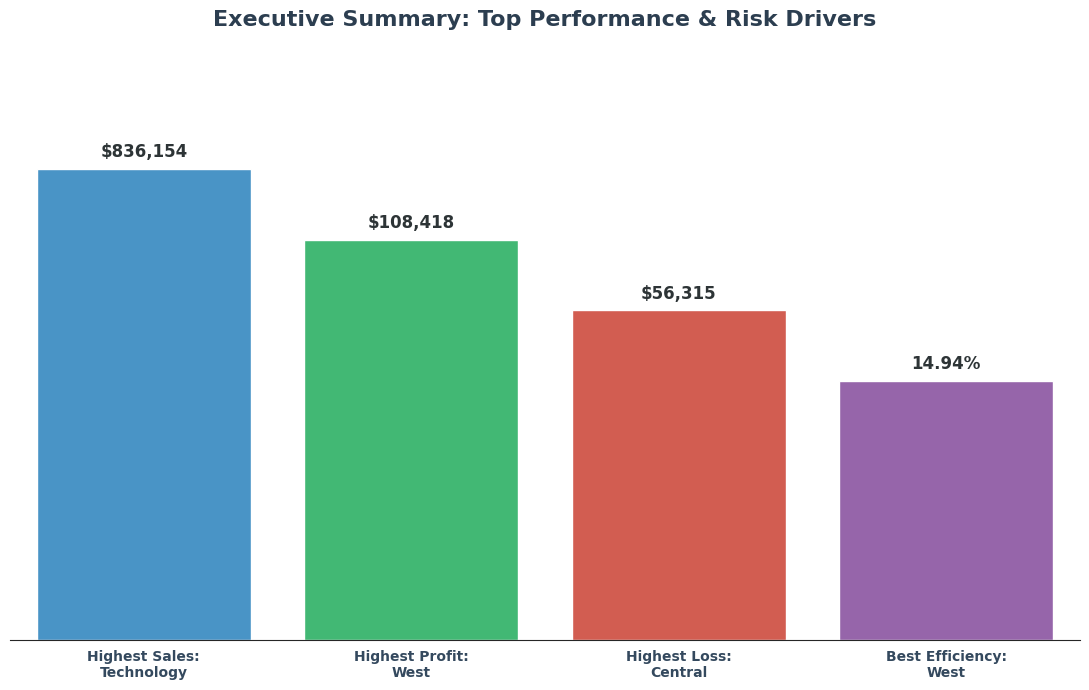

In [84]:
labels = [
    f"Highest Sales:\n{top_sales_cat['Product Category']}",
    f"Highest Profit:\n{top_profit_reg['Region']}",
    f"Highest Loss:\n{top_loss_reg['Region']}",
    f"Best Efficiency:\n{best_perf_reg['Region']}"
]

formatted_labels = [
    f"${top_sales_cat['Total Sales ($)']:,.0f}",
    f"${top_profit_reg.iloc[2]:,.0f}",
    f"${top_loss_reg.iloc[3]:,.0f}",
    f"{best_perf_reg.iloc[4]:.2f}%"
]

values_plot = [1.0, 0.85, 0.70, 0.55]
plt.figure(figsize=(11, 7))
sns.set_style("white")

custom_palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
ax = sns.barplot(x=labels, y=values_plot, hue=labels, palette=custom_palette, legend=False)

for i, p in enumerate(ax.patches):
    ax.annotate(formatted_labels[i],
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 12),
                textcoords = 'offset points',
                fontsize=12,
                fontweight='bold',
                color='#2d3436')

plt.title("Executive Summary: Top Performance & Risk Drivers",
          fontsize=16, fontweight='bold', pad=35, color='#2c3e50')

plt.xlabel("")
plt.ylabel("")

sns.despine(left=True)
ax.set_yticks([])
ax.set_yticklabels([])

plt.xticks(fontsize=10, fontweight='bold', color='#34495e')

plt.ylim(0, 1.2)

plt.tight_layout()
plt.savefig('executive_summary_final_vibe.png', dpi=300, bbox_inches='tight')
plt.show()

Final Conclusion: Strategic Business Performance Insights
Based on the data-driven analysis of the Global Superstore Dataset, we can provide definitive answers to the project's core questions:

###1. Which category sells the most? (The Revenue Engine)**

The Technology category is the clear leader in sales volume, generating over $836,154. Although it is the high-ticket driver of the company, the analysis shows that high revenue doesn't always mean the highest efficiency, as some sub-categories within Technology face aggressive discounting that can squeeze margins.

###2. Where do we have the highest profit or the biggest losses?

The Profit Leader: The West region is the powerhouse of the operation, delivering the highest total profit. This success is driven by a healthy mix of high-volume sales and disciplined discounting.

The Critical Loss Point: The Central region represents the highest financial risk. It record the biggest absolute losses, largely due to "Texas" and "Illinois," where excessive discounts often exceed the cost of goods sold, turning potential revenue into net deficits.

###3. Which regions are performing the best? (Operational Efficiency)
While the West leads in volume, the West also maintains the best balance, but in terms of pure Profit Margin (%), it stands out as the most efficient. A high profit margin here indicates that for every dollar sold, the company retains more value compared to the Central region, which, despite having significant sales, suffers from a "leak" in profitability due to high operational costs and loss impacts.